# 1. Preprocessing

## a. Data load and check
Memeriksa informasi-informasi awal dari data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.DataFrame(pd.read_csv("Student_Mental_health.csv"))
df

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

In [4]:
df.duplicated().sum()

0

## b. Data Cleaning
Isinya bersih bersih data, kaya hapus data ga penting, fill data NaN

In [5]:
df.columns = ['Timestamp','Gender','Age','Course','Year','CGPA',
              'Marital','Depression','Anxiety','Panic','Treatment']
df['Course'] = df['Course'].str.strip()

In [6]:
df.drop("Timestamp", axis=1, inplace=True)
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [7]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [8]:
df['Year'] = df['Year'].str.replace('year', '', case=False).str.strip().astype(int)

In [9]:
# Mencari baris yang memiliki nilai NaN pada kolom Age
df[df['Age'].isna()]

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment
43,Male,NaN,BIT,1,0 - 1.99,No,No,No,No,No


In [10]:
print(df[df["Year"] == 1]["Age"].median())
df['Age'] = df['Age'].fillna(df[df["Year"] == 1]["Age"].median())

19.0


In [11]:
print(df.isna().sum())

Gender        0
Age           0
Course        0
Year          0
CGPA          0
Marital       0
Depression    0
Anxiety       0
Panic         0
Treatment     0
dtype: int64


In [12]:
df['CGPA'].unique()

array(['3.00 - 3.49', '3.50 - 4.00', '3.50 - 4.00 ', '2.50 - 2.99',
       '2.00 - 2.49', '0 - 1.99'], dtype=object)

In [13]:
df['CGPA'] = df['CGPA'].str.strip()

In [14]:
df['CGPA'].unique()

array(['3.00 - 3.49', '3.50 - 4.00', '2.50 - 2.99', '2.00 - 2.49',
       '0 - 1.99'], dtype=object)

## c. EDA
Liat liat dulu statistik datanya

In [15]:
sns.set_theme(style="whitegrid")
MENTAL_COLS = ['Depression', 'Anxiety', 'Panic']

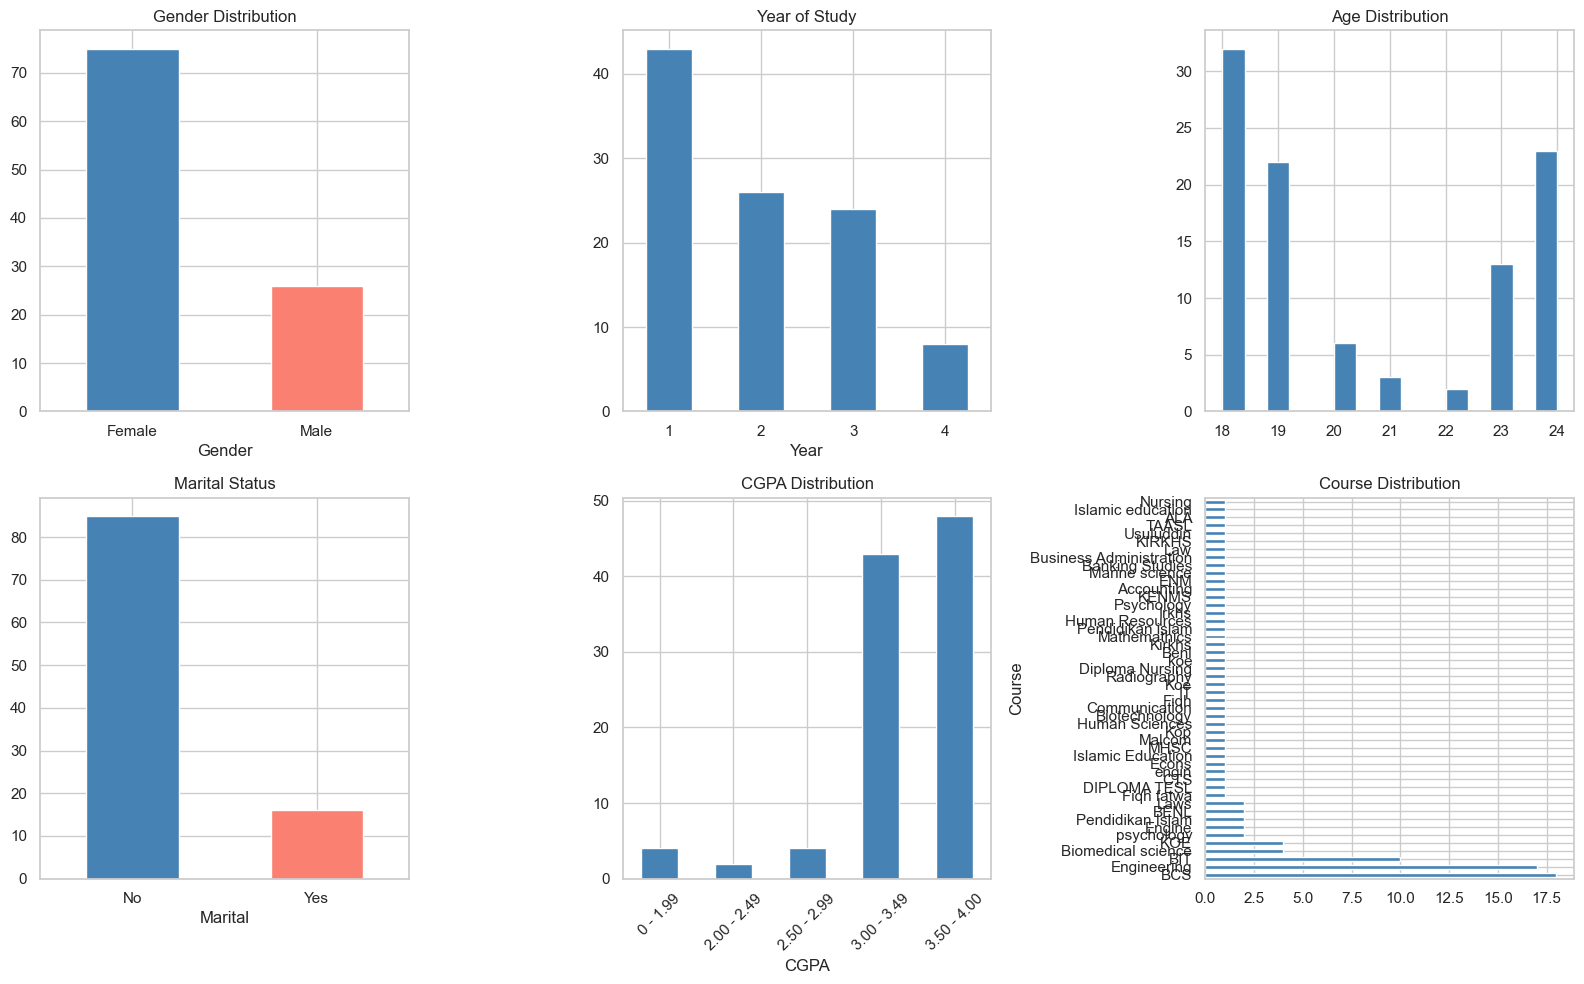

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Gender
df['Gender'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','salmon'])
axes[0,0].set_title('Gender Distribution')
axes[0,0].tick_params(axis='x', rotation=0)

# Year
df['Year'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Year of Study')
axes[0,1].tick_params(axis='x', rotation=0)

# Age
axes[0,2].hist(df['Age'], bins=15, color='steelblue', edgecolor='white')
axes[0,2].set_title('Age Distribution')

# Marital Status
df['Marital'].value_counts().plot(kind='bar', ax=axes[1,0], color=['steelblue','salmon'])
axes[1,0].set_title('Marital Status')
axes[1,0].tick_params(axis='x', rotation=0)

# CGPA
df['CGPA'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('CGPA Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

# Course
df['Course'].value_counts().plot(kind='barh', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Course Distribution')

plt.tight_layout()
plt.show()

Insights:
- Female jauh lebih banyak yang ngisi. Ada kemungkinan modelnya bias dan lebih apal pola female.
- Mahasiswa tahun awal lebih sering ngisi.
- Pola age bentuknya kaya parabola, gede di awal dan akhir, di tengah dikit.
- Dikit banget yang nikah. Bisa dilihat nanti apakah yang nikah memiliki relation yang kuat ke kondisi tertentu.
- CGPA banyak yang di atas 3.00. Sedikit yang ada di bawah 2.99, memungkinkan untuk binning.
- Course terlalu sparse, cluttered banget, asli. Nanti di grouping dah mending.


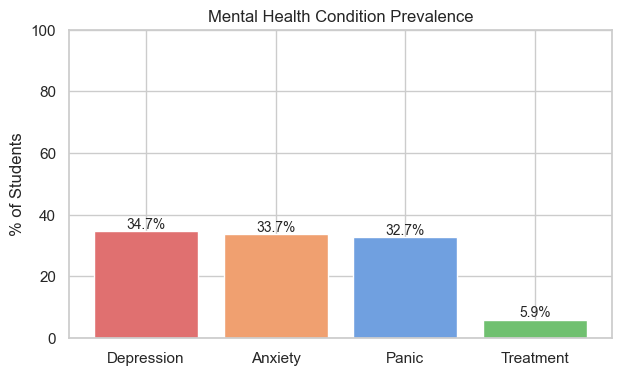

In [17]:
prevalence = df[MENTAL_COLS + ['Treatment']].apply(lambda col: (col == 'Yes').mean() * 100)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(prevalence.index, prevalence.values, color=['#e07070','#f0a070','#70a0e0','#70c070'])
ax.set_ylabel('% of Students')
ax.set_title('Mental Health Condition Prevalence')
ax.set_ylim(0, 100)

for bar, val in zip(bars, prevalence.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)

plt.show()

Lumayan rata, dan yang treatment dikit, menarik. Bisa diolah nanti

In [18]:
mental_binary = df[MENTAL_COLS].apply(lambda col: (col == 'Yes').astype(int))
combos = mental_binary.groupby(MENTAL_COLS).size().reset_index(name='Count').sort_values('Count', ascending=False)
print(combos.to_string(index=False))

 Depression  Anxiety  Panic  Count
          0        0      0     37
          0        0      1     13
          0        1      0     13
          1        0      0     10
          1        1      1     10
          1        1      0      8
          1        0      1      7
          0        1      1      3


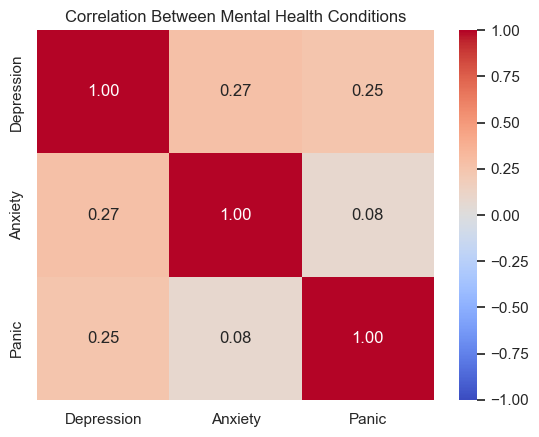

In [19]:
corr = mental_binary.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Mental Health Conditions')
plt.show()

Menarik, ga terlalu ada keterkaitan mutlak satu sama lain, mungkin nanti bisa diambil insightnya.

C:\Users\LOQ\AppData\Local\Temp\ipykernel_20472\2977316196.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_20472\2977316196.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_20472\2977316196.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')


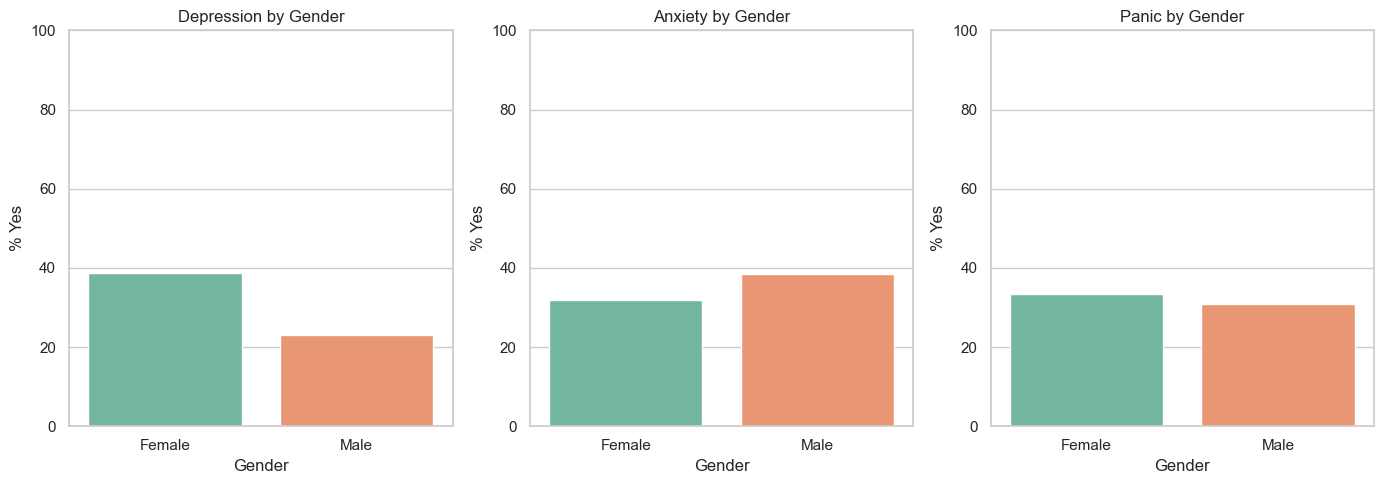

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Gender')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Gender', 'Pct']
    sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Gender')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Tidak ada dominasi atau kecenderungan mutlak dari gender terhadap keadaan mental.

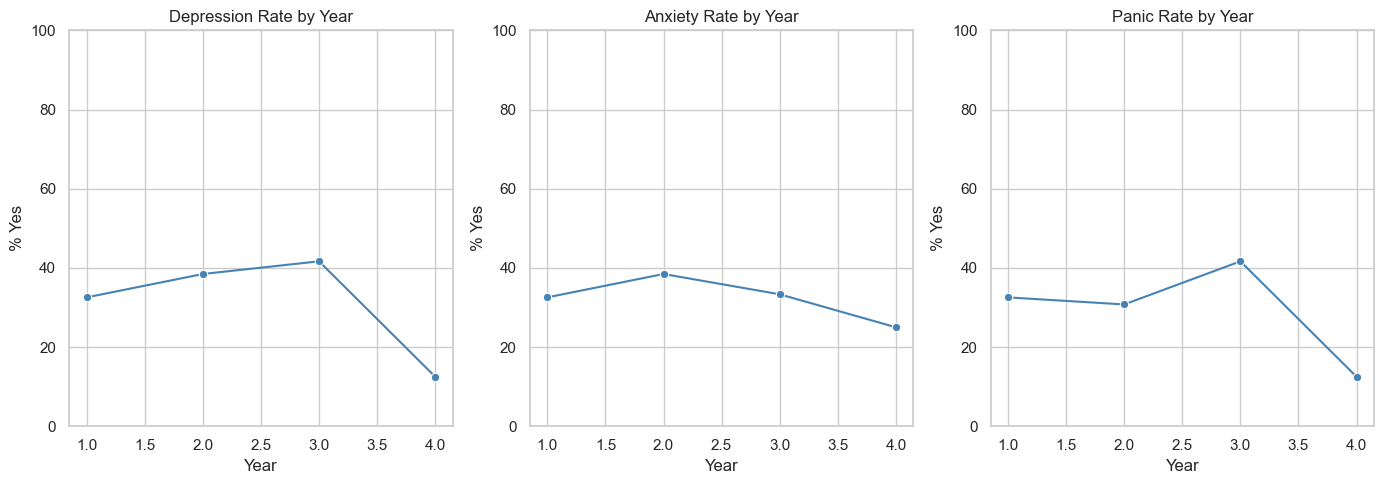

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Year')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Year', 'Pct']
    sns.lineplot(data=ct, x='Year', y='Pct', ax=ax, marker='o', color='steelblue')
    ax.set_title(f'{col} Rate by Year')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Terlihat depresi dan panic rate paling tinggi ada di tahun ke 3, dan anxiety di tahun ke 2.

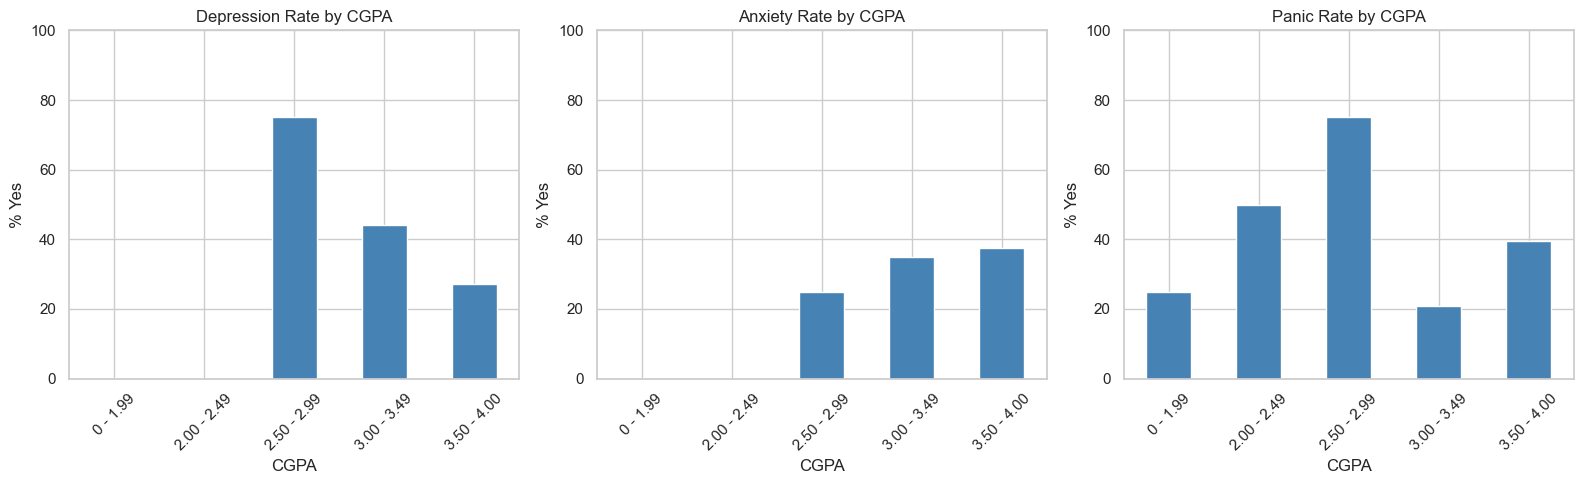

In [22]:
cgpa_order = sorted(df['CGPA'].unique())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('CGPA')[col].apply(lambda x: (x == 'Yes').mean() * 100).reindex(cgpa_order)
    ct.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{col} Rate by CGPA')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Tren dari setiap kondisi mental berbeda-beda jika dilihat berdasarkan CGPA. Depression rate memiliki tren yang menurun mulai dari 2.5. Anxiety memiliki tren naik. Panic rate tidak terlalu memiliki tren yang jelas, namun mahasiswa dengan CGPA yang rendah memiliki kondisi Panic.

In [23]:
df['Any_condition'] = df[MENTAL_COLS].apply(lambda row: 'Yes' in row.values, axis=1)

ct = pd.crosstab(df['Any_condition'], df['Treatment'])
ct.index = ['No Condition', 'Has Condition']
ct.columns = ['No Treatment', 'Seeking Treatment']
print(ct)
print()
print("Of students WITH a condition, % seeking treatment:",
      round(ct.loc['Has Condition', 'Seeking Treatment'] / ct.loc['Has Condition'].sum() * 100, 1), "%")

               No Treatment  Seeking Treatment
No Condition             37                  0
Has Condition            58                  6

Of students WITH a condition, % seeking treatment: 9.4 %


Uih, SANGAT sedikit mahasiswa dengan setidaknya satu kondisi mental yang mencari pertolongan profesional

C:\Users\LOQ\AppData\Local\Temp\ipykernel_20472\1090019286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Marital', y='Pct', ax=ax, palette='Set2')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_20472\1090019286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Marital', y='Pct', ax=ax, palette='Set2')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_20472\1090019286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Marital', y='Pct', ax=ax, palette='Set2')


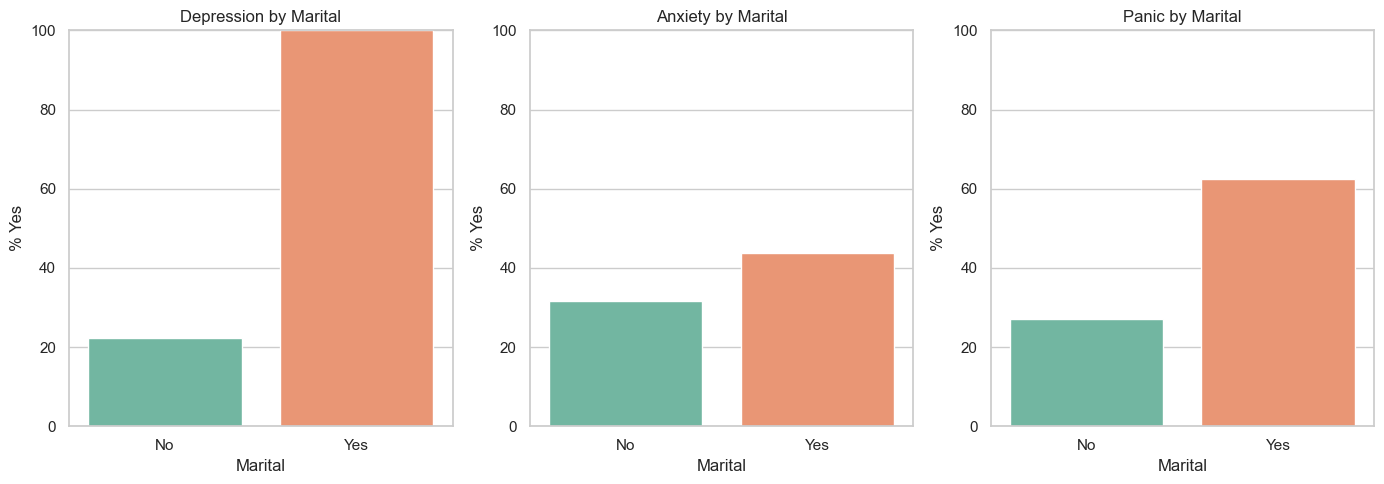

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Marital')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Marital', 'Pct']
    sns.barplot(data=ct, x='Marital', y='Pct', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Marital')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [25]:
df[df["Marital"] == "Yes"]

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True
6,Female,23.0,Pendidikan islam,2,3.50 - 4.00,Yes,Yes,No,Yes,No,True
11,Female,24.0,Engineering,3,3.50 - 4.00,Yes,Yes,No,No,No,True
17,Female,24.0,ENM,4,3.00 - 3.49,Yes,Yes,Yes,Yes,No,True
19,Female,18.0,Marine science,2,3.50 - 4.00,Yes,Yes,Yes,Yes,No,True
27,Male,18.0,Engineering,2,3.00 - 3.49,Yes,Yes,Yes,No,No,True
28,Female,24.0,BIT,3,3.50 - 4.00,Yes,Yes,Yes,Yes,Yes,True
33,Male,18.0,BCS,2,3.50 - 4.00,Yes,Yes,Yes,No,Yes,True
39,Female,24.0,Engineering,2,2.50 - 2.99,Yes,Yes,No,Yes,Yes,True
50,Female,23.0,ALA,1,2.50 - 2.99,Yes,Yes,No,Yes,Yes,True


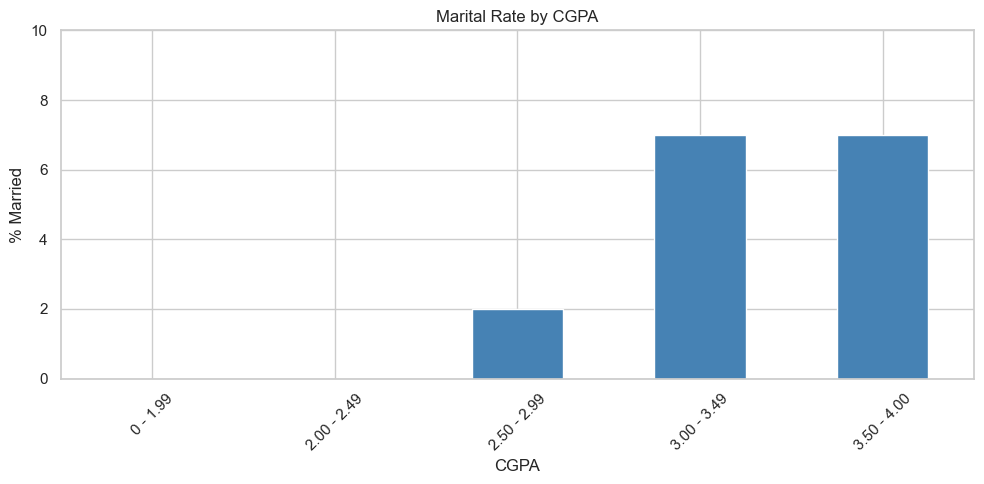

In [26]:
cgpa_order = sorted(df['CGPA'].unique())

fig, ax = plt.subplots(figsize=(10, 5))

ct = (
    df.groupby('CGPA')['Marital']
    .apply(lambda x: (x == 'Yes').sum())
    .reindex(cgpa_order)
)

ct.plot(kind='bar', ax=ax, color='steelblue')

ax.set_title('Marital Rate by CGPA')
ax.set_ylabel('% Married')
ax.set_xlabel('CGPA')
ax.set_ylim(0, 10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

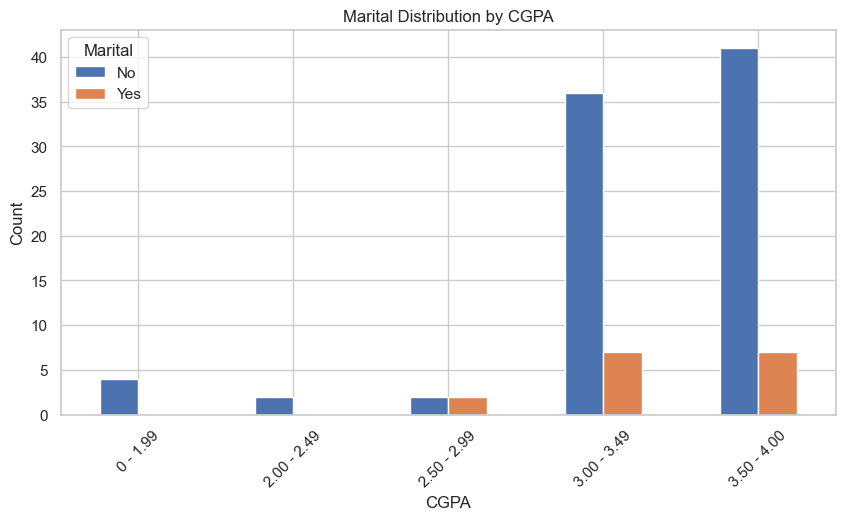

In [27]:
pd.crosstab(df['CGPA'], df['Marital']).reindex(cgpa_order).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Marital Distribution by CGPA')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Dari sini, kita bisa lihat bahwa orang yang menikah berada di rentang CGPA 2.5-4.00 dengan tren naik, yang mana sama dengan tren seluruh mahasiswa secara general. Tidak ada insight yang berarti yang dapat diambil disini.

In [28]:
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition
0,Female,18.0,Engineering,1,3.00 - 3.49,No,Yes,No,Yes,No,True
1,Male,21.0,Islamic education,2,3.00 - 3.49,No,No,Yes,No,No,True
2,Male,19.0,BIT,1,3.00 - 3.49,No,Yes,Yes,Yes,No,True
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True
4,Male,23.0,Mathemathics,4,3.00 - 3.49,No,No,No,No,No,False
...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,1,3.50 - 4.00,No,No,Yes,No,No,True
97,Male,18.0,Engineering,2,3.00 - 3.49,No,Yes,Yes,No,No,True
98,Female,19.0,Nursing,3,3.50 - 4.00,Yes,Yes,No,Yes,No,True
99,Female,23.0,Pendidikan Islam,4,3.50 - 4.00,No,No,No,No,No,False


## d. Feature Engineering
Mulai otak-atik fitur, misal grouping, dll.

In [29]:
df['Course'].unique()

array(['Engineering', 'Islamic education', 'BIT', 'Laws', 'Mathemathics',
       'Pendidikan islam', 'BCS', 'Human Resources', 'Irkhs',
       'Psychology', 'KENMS', 'Accounting', 'ENM', 'Marine science',
       'KOE', 'Banking Studies', 'Business Administration', 'Law',
       'KIRKHS', 'Usuluddin', 'TAASL', 'Engine', 'ALA',
       'Biomedical science', 'koe', 'Kirkhs', 'BENL', 'Benl', 'IT', 'CTS',
       'engin', 'Econs', 'MHSC', 'Malcom', 'Kop', 'Human Sciences',
       'Biotechnology', 'Communication', 'Diploma Nursing',
       'Pendidikan Islam', 'Radiography', 'psychology', 'Fiqh fatwa',
       'DIPLOMA TESL', 'Koe', 'Fiqh', 'Islamic Education', 'Nursing'],
      dtype=object)

In [30]:
course_clean_mapping = {
    'Engineering'           : 'Engineering',
    'Engine'                : 'Engineering',
    'engin'                 : 'Engineering',
    'KOE'                   : 'Engineering',
    'koe'                   : 'Engineering',
    'Koe'                   : 'Engineering',
    'BCS'                   : 'BCS',
    'BIT'                   : 'BIT',
    'IT'                    : 'BIT',
    'CTS'                   : 'BIT',
    'Biomedical science'    : 'Biomedical Science',
    'Biotechnology'         : 'Biotechnology',
    'Mathemathics'          : 'Mathematics',
    'Marine science'        : 'Marine Science',
    'Islamic education'     : 'Islamic Education',
    'Islamic Education'     : 'Islamic Education',
    'Pendidikan islam'      : 'Islamic Education',
    'Pendidikan Islam'      : 'Islamic Education',
    'Irkhs'                 : 'Islamic Education',
    'KIRKHS'                : 'Islamic Education',
    'Kirkhs'                : 'Islamic Education',
    'Fiqh fatwa'            : 'Islamic Education',
    'Fiqh'                  : 'Islamic Education',
    'Usuluddin'             : 'Islamic Education',
    'MHSC'                  : 'Islamic Education',
    'Malcom'                : 'Islamic Education',
    'BENL'                  : 'English Language',
    'Benl'                  : 'English Language',
    'TAASL'                 : 'English Language',
    'ALA'                   : 'English Language',
    'DIPLOMA TESL'          : 'English Language',
    'Human Resources'       : 'Human Sciences',
    'Human Sciences'        : 'Human Sciences',
    'Psychology'            : 'Psychology',
    'psychology'            : 'Psychology',
    'Laws'                  : 'Law',
    'Law'                   : 'Law',
    'Nursing'               : 'Nursing',
    'Diploma Nursing'       : 'Nursing',
    'Radiography'           : 'Radiography',
    'Communication'         : 'Communication',
    'Econs'                 : 'Economics',
    'ENM'                   : 'Economics',
    'KENMS'                 : 'Economics',
    'Business Administration': 'Business Administration',
    'Banking Studies'       : 'Banking Studies',
    'Accounting'            : 'Accounting',
    'Kop'                   : 'Pharmacy',
}

In [31]:
rumpun_mapping = {
    # STEM
    'Engineering'           : 'STEM',
    'BCS'                   : 'STEM',
    'BIT'                   : 'STEM',
    'Biomedical Science'    : 'STEM',
    'Biotechnology'         : 'STEM',
    'Mathematics'           : 'STEM',
    'Marine Science'        : 'STEM',
    'Pharmacy'              : 'STEM',
 
    # Social & Humanities (termasuk Islamic Education, Health, Language)
    'Islamic Education'         : 'Social Sciences & Humanities',
    'English Language'          : 'Social Sciences & Humanities',
    'Human Sciences'            : 'Social Sciences & Humanities',
    'Psychology'                : 'Social Sciences & Humanities',
    'Law'                       : 'Social Sciences & Humanities',
    'Nursing'                   : 'Social Sciences & Humanities',
    'Radiography'               : 'Social Sciences & Humanities',
    'Communication'             : 'Social Sciences & Humanities',
    'Economics'                 : 'Social Sciences & Humanities',
    'Business Administration'   : 'Social Sciences & Humanities',
    'Banking Studies'           : 'Social Sciences & Humanities',
    'Accounting'                : 'Social Sciences & Humanities'
 }

In [32]:
df['Course_clean'] = df['Course'].map(course_clean_mapping)
df['Course_group'] = df['Course_clean'].map(rumpun_mapping)

In [33]:
unmapped = df[df['Course_group'].isna()]['Course'].unique()
if len(unmapped) > 0:
    print("Unmapped:", unmapped)
else:
    print("Mapping ok")

Mapping ok


In [34]:
print("Detail Mapping")
detail = df.groupby('Course_group')['Course_clean'].apply(lambda x: sorted(x.unique())).reset_index()
for _, row in detail.iterrows():
    print(f"\n  [{row['Course_group']}]")
    for c in row['Course_clean']:
        print(f"    - {c}")
 
print("\n=== DISTRIBUSI FINAL ===")
dist = df['Course_group'].value_counts()
for group, count in dist.items():
    bar = '█' * count
    pct = count / len(df) * 100
    print(f"  {group:<25} {count:>3} ({pct:4.1f}%)  {bar}")

Detail Mapping

  [STEM]
    - BCS
    - BIT
    - Biomedical Science
    - Biotechnology
    - Engineering
    - Marine Science
    - Mathematics
    - Pharmacy

  [Social Sciences & Humanities]
    - Accounting
    - Banking Studies
    - Business Administration
    - Communication
    - Economics
    - English Language
    - Human Sciences
    - Islamic Education
    - Law
    - Nursing
    - Psychology
    - Radiography

=== DISTRIBUSI FINAL ===
  STEM                       64 (63.4%)  ████████████████████████████████████████████████████████████████
  Social Sciences & Humanities  37 (36.6%)  █████████████████████████████████████


In [35]:
def risk_level(row):
    score = (row['Depression']=='Yes') + (row['Anxiety']=='Yes') + (row['Panic']=='Yes')
    if score == 0: return 'Low'
    elif score == 1: return 'Medium'
    else: return 'High'
    
df['Risk_Level'] = df.apply(risk_level, axis=1)
 
print("\nRisk Level Per Rumpun")
ct = pd.crosstab(df['Course_group'], df['Risk_Level'])
ct['Total'] = ct.sum(axis=1)
ct['High%'] = (ct.get('High', 0) / ct['Total'] * 100).round(1)
print(ct.to_string())


Risk Level Per Rumpun
Risk_Level                    High  Low  Medium  Total  High%
Course_group                                                 
STEM                            16   23      25     64   25.0
Social Sciences & Humanities    12   14      11     37   32.4


In [36]:
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition,Course_clean,Course_group,Risk_Level
0,Female,18.0,Engineering,1,3.00 - 3.49,No,Yes,No,Yes,No,True,Engineering,STEM,High
1,Male,21.0,Islamic education,2,3.00 - 3.49,No,No,Yes,No,No,True,Islamic Education,Social Sciences & Humanities,Medium
2,Male,19.0,BIT,1,3.00 - 3.49,No,Yes,Yes,Yes,No,True,BIT,STEM,High
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True,Law,Social Sciences & Humanities,Medium
4,Male,23.0,Mathemathics,4,3.00 - 3.49,No,No,No,No,No,False,Mathematics,STEM,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,1,3.50 - 4.00,No,No,Yes,No,No,True,BCS,STEM,Medium
97,Male,18.0,Engineering,2,3.00 - 3.49,No,Yes,Yes,No,No,True,Engineering,STEM,High
98,Female,19.0,Nursing,3,3.50 - 4.00,Yes,Yes,No,Yes,No,True,Nursing,Social Sciences & Humanities,High
99,Female,23.0,Pendidikan Islam,4,3.50 - 4.00,No,No,No,No,No,False,Islamic Education,Social Sciences & Humanities,Low


In [37]:
df.drop(['Course', 'Depression', 'Anxiety', 'Panic'], axis=1, inplace=True)
df.rename(columns={'Course_clean': 'Course'}, inplace=True)

In [38]:
df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,STEM,High
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Social Sciences & Humanities,Medium
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,STEM,High
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Social Sciences & Humanities,Medium
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,STEM,Low
...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,STEM,Medium
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,STEM,High
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Social Sciences & Humanities,High
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Social Sciences & Humanities,Low


In [39]:
df['Silent_Sufferer'] = ((df['Any_condition'] == True) & (df['Treatment'] == 'No'))
df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level,Silent_Sufferer
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,STEM,High,True
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Social Sciences & Humanities,Medium,True
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,STEM,High,True
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Social Sciences & Humanities,Medium,True
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,STEM,Low,False
...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,STEM,Medium,True
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,STEM,High,True
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Social Sciences & Humanities,High,True
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Social Sciences & Humanities,Low,False


<function matplotlib.pyplot.show(close=None, block=None)>

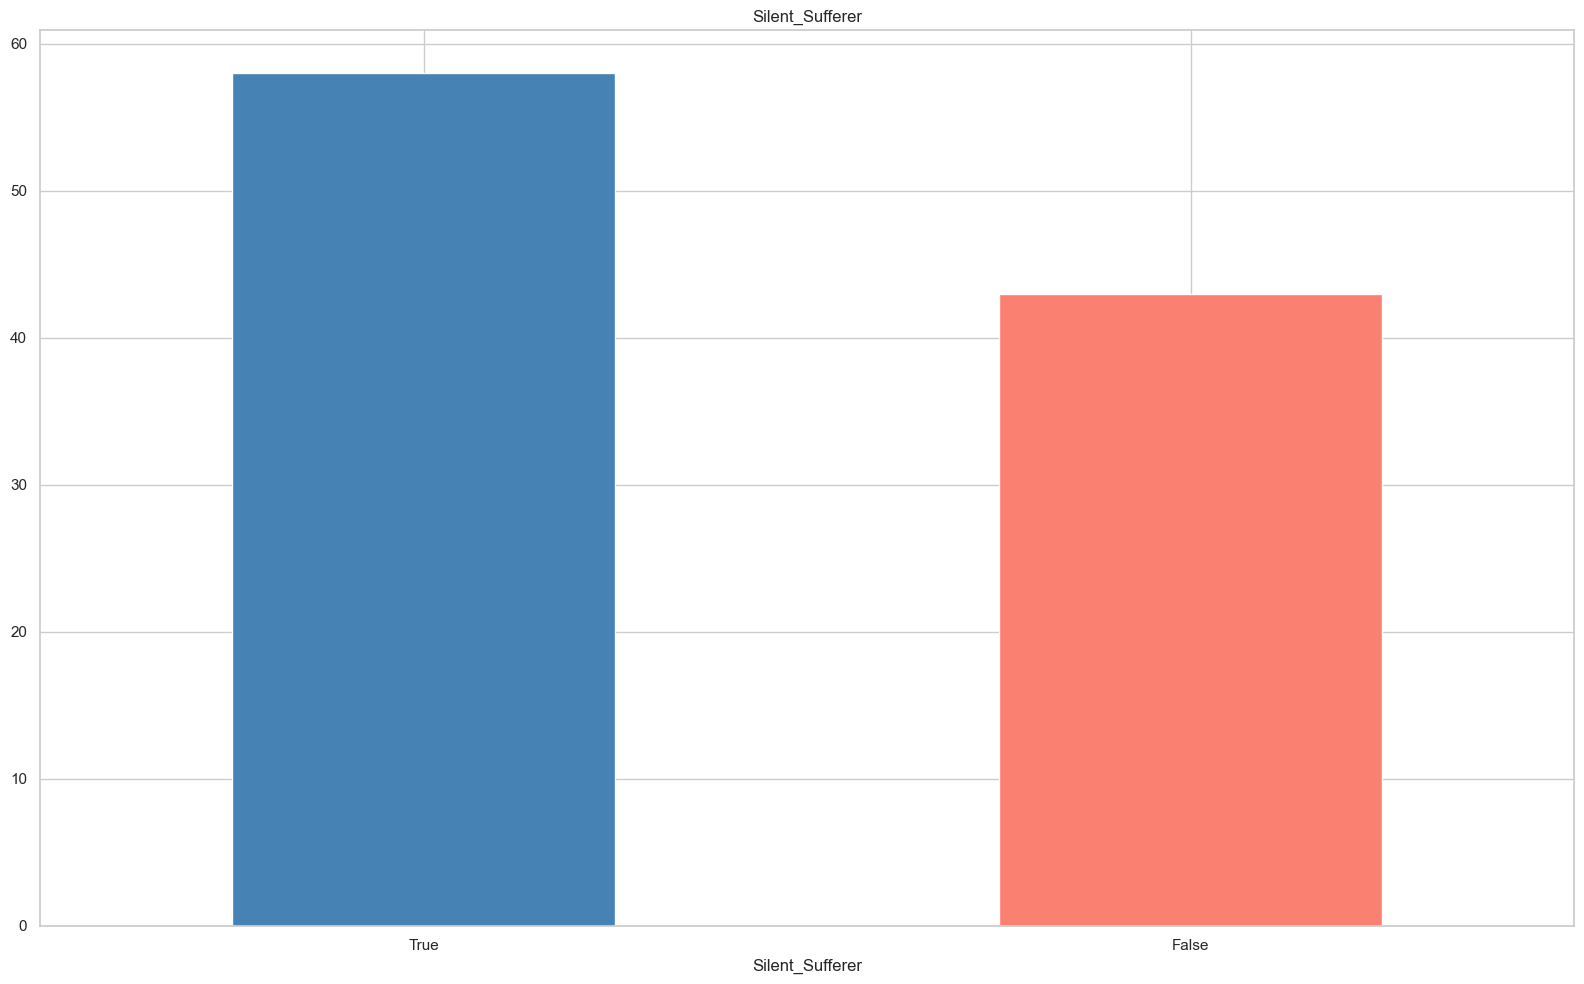

In [40]:
fig, axes = plt.subplots(1,1,figsize=(16, 10))

# Gender
df['Silent_Sufferer'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
axes.set_title('Silent_Sufferer')
axes.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show

In [41]:
def simplify_cgpa(cgpa):
    if cgpa in ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99']:
        return 'Below 3.00'
    return cgpa

df['CGPA_grouped'] = df['CGPA'].apply(simplify_cgpa)

df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level,Silent_Sufferer,CGPA_grouped
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,STEM,High,True,3.00 - 3.49
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Social Sciences & Humanities,Medium,True,3.00 - 3.49
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,STEM,High,True,3.00 - 3.49
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Social Sciences & Humanities,Medium,True,3.00 - 3.49
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,STEM,Low,False,3.00 - 3.49
...,...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,STEM,Medium,True,3.50 - 4.00
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,STEM,High,True,3.00 - 3.49
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Social Sciences & Humanities,High,True,3.50 - 4.00
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Social Sciences & Humanities,Low,False,3.50 - 4.00


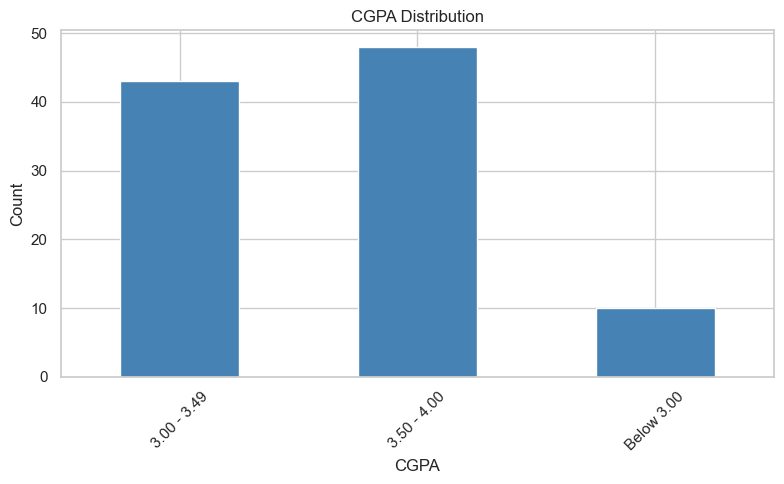

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

df['CGPA_grouped'].value_counts().sort_index().plot(
    kind='bar',
    ax=ax,
    color='steelblue'
)

ax.set_title('CGPA Distribution')
ax.set_xlabel('CGPA')
ax.set_ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
for col in ['Marital', 'Treatment']:
    df[col] = df[col].map({
        'Yes': True,
        'No': False
    })

In [44]:
df['Gender'] = df['Gender'].map({
    'Male': True,
    'Female': False
})

In [45]:
df['Course_group'] = df['Course_group'].map({
    'STEM': True,
    'Social Sciences & Humanities': False
})

In [46]:
df['CGPA_grouped'].unique()

array(['3.00 - 3.49', '3.50 - 4.00', 'Below 3.00'], dtype=object)

In [47]:
df['CGPA_grouped'] = pd.Categorical(
    df['CGPA_grouped'],
    categories=['Below 3.00', '3.00 - 3.49', '3.50 - 4.00'],
    ordered=True
)
df['CGPA_grouped_encoded'] = df['CGPA_grouped'].cat.codes

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Gender                101 non-null    bool    
 1   Age                   101 non-null    float64 
 2   Year                  101 non-null    int32   
 3   CGPA                  101 non-null    object  
 4   Marital               101 non-null    bool    
 5   Treatment             101 non-null    bool    
 6   Any_condition         101 non-null    bool    
 7   Course                101 non-null    object  
 8   Course_group          101 non-null    bool    
 9   Risk_Level            101 non-null    object  
 10  Silent_Sufferer       101 non-null    bool    
 11  CGPA_grouped          101 non-null    category
 12  CGPA_grouped_encoded  101 non-null    int8    
dtypes: bool(6), category(1), float64(1), int32(1), int8(1), object(3)
memory usage: 4.6+ KB


In [49]:
df.drop(columns=['CGPA', 'Course', 'Treatment', 'Any_condition','Risk_Level', 'CGPA_grouped'], inplace=True)
df

,Gender,Age,Year,Marital,Course_group,Silent_Sufferer,CGPA_grouped_encoded
0,False,18.0,1,False,True,True,1
1,True,21.0,2,False,False,True,1
2,True,19.0,1,False,True,True,1
3,False,22.0,3,True,False,True,1
4,True,23.0,4,False,True,False,1
...,...,...,...,...,...,...,...
96,False,21.0,1,False,True,True,2
97,True,18.0,2,False,True,True,1
98,False,19.0,3,True,False,True,2
99,False,23.0,4,False,False,False,2


Dapat disimpulkan bahwa disini kami memiliki 6 fitur dan 1 target, yakni
Fitur:
- Gender
- Age
- Year
- Marital
- Course_group
- CGPA_grouped_encoded

Target:
- Silent_Sufferer

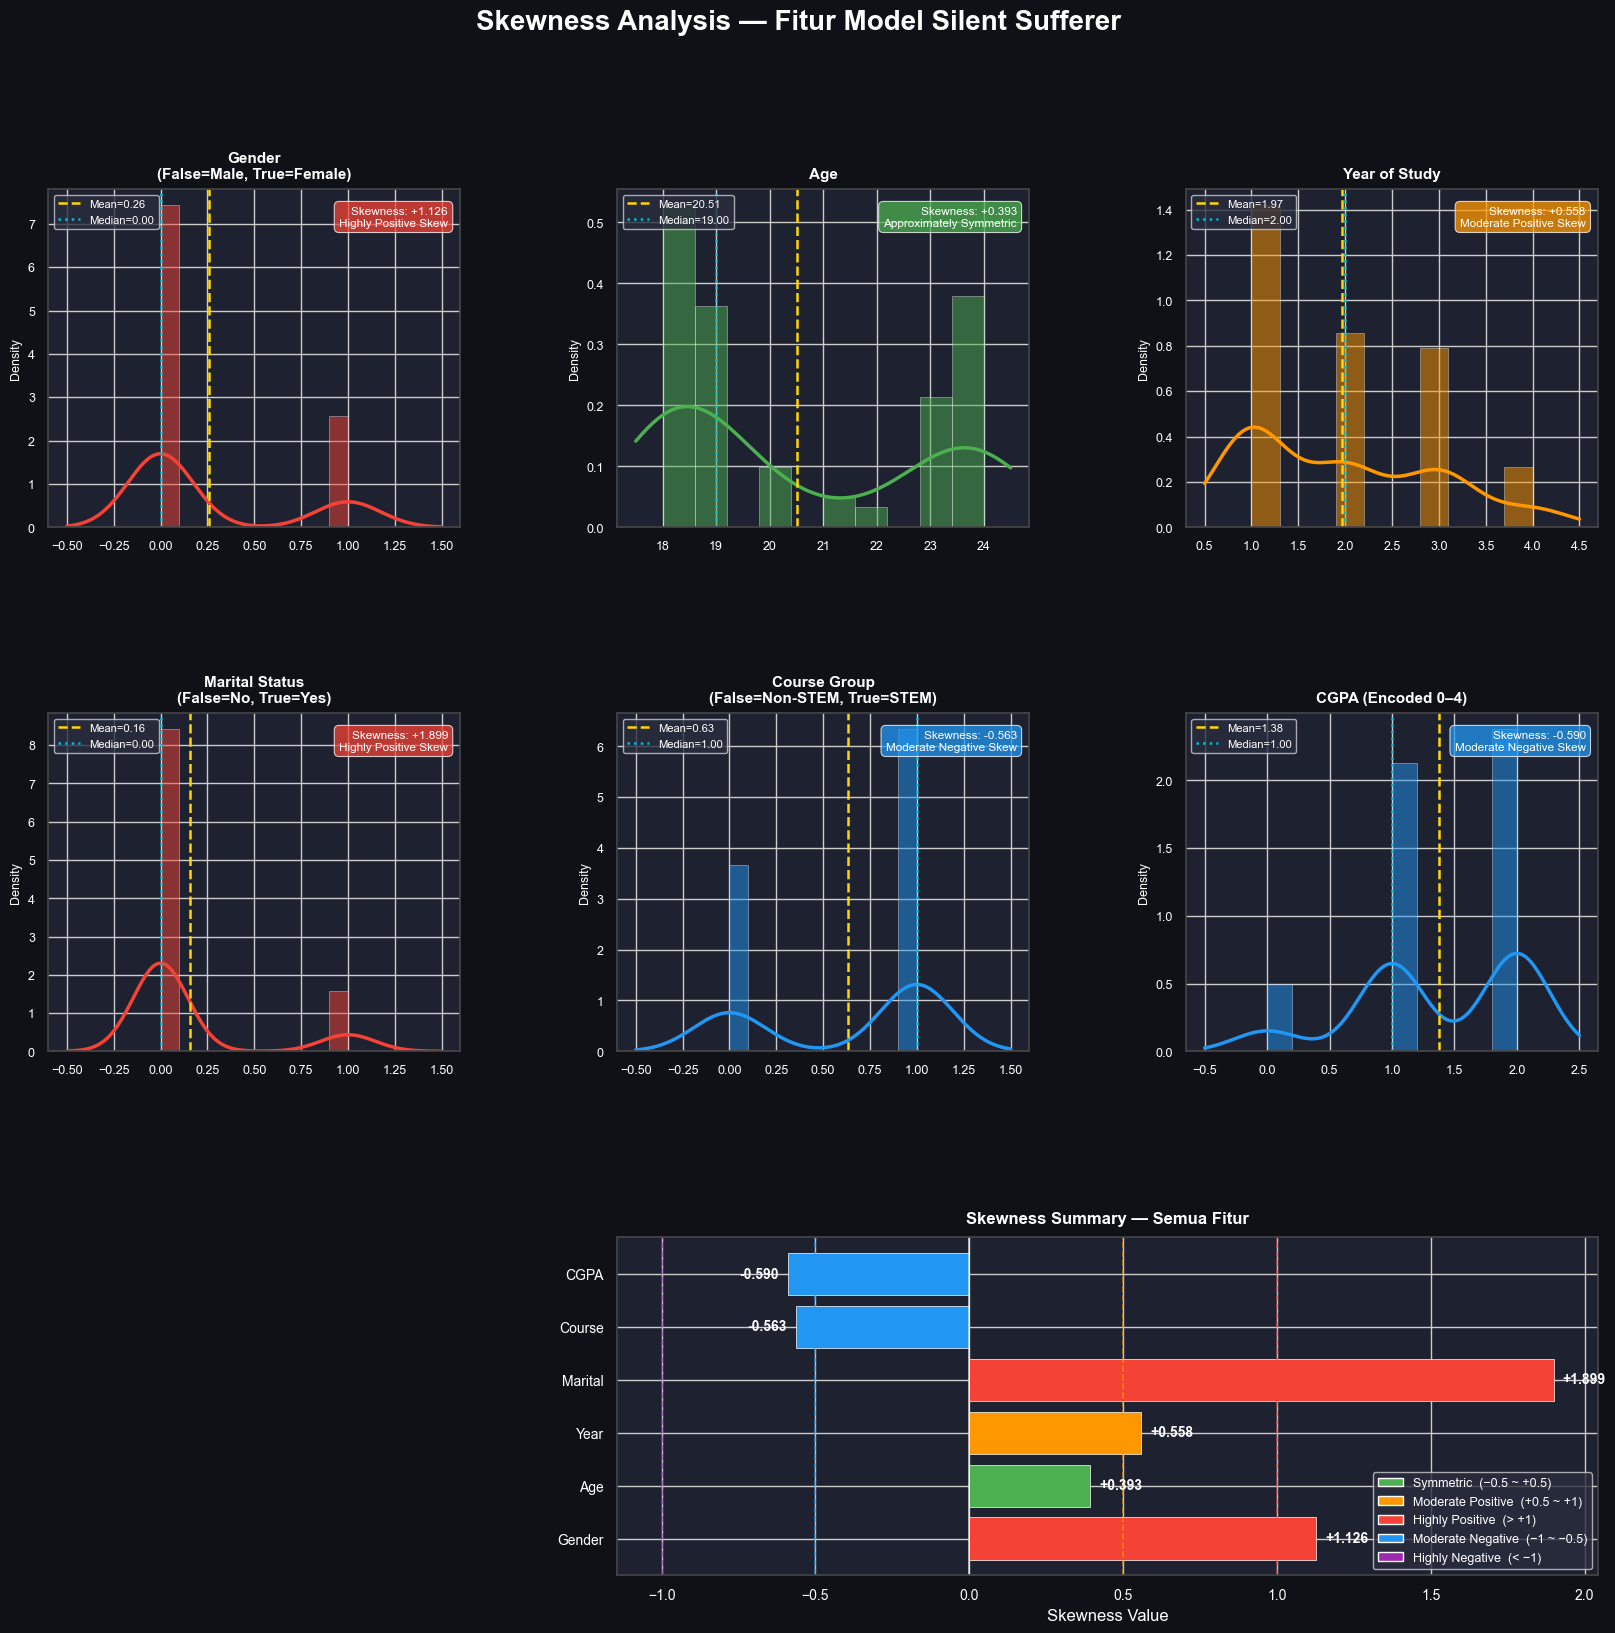

In [ ]:
from scipy import stats
import matplotlib.patches as mpatches

# Fitur yang akan dianalisis skewness-nya
features     = ['Gender', 'Age', 'Year', 'Marital', 'Course_group', 'CGPA_grouped_encoded']
col_labels   = {
    'Gender'              : 'Gender\n(False=Male, True=Female)',
    'Age'                 : 'Age',
    'Year'                : 'Year of Study',
    'Marital'             : 'Marital Status\n(False=No, True=Yes)',
    'Course_group'        : 'Course Group\n(False=Non-STEM, True=STEM)',
    'CGPA_grouped_encoded': 'CGPA (Encoded 0–4)',
}

# Konversi bool ke int supaya skew() bisa dihitung
df_skew = df[features].copy()
for col in df_skew.select_dtypes(include='bool').columns:
    df_skew[col] = df_skew[col].astype(int)

# Helper: warna & label berdasarkan nilai skewness
def get_skew_info(val):
    if   val >  1.0: return '#F44336', 'Highly Positive Skew'
    elif val >  0.5: return '#FF9800', 'Moderate Positive Skew'
    elif val >= -0.5: return '#4CAF50', 'Approximately Symmetric'
    elif val >= -1.0: return '#2196F3', 'Moderate Negative Skew'
    else:            return '#9C27B0', 'Highly Negative Skew'

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18), facecolor='#0f1117')
fig.suptitle('Skewness Analysis — Fitur Model Silent Sufferer',
             fontsize=20, fontweight='bold', color='white', y=0.98)

gs       = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.38)
bg_ax    = '#1e2130'
txt_col  = 'white'

skew_summary = {}

for idx, col in enumerate(features):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    ax.set_facecolor(bg_ax)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

    data     = df_skew[col].dropna()
    skew_val = float(data.skew())
    skew_summary[col] = skew_val
    color, label = get_skew_info(skew_val)

    # Histogram + KDE
    ax.hist(data, bins=10, color=color, alpha=0.5,
            edgecolor='white', linewidth=0.5, density=True)
    kde_x = np.linspace(data.min() - 0.5, data.max() + 0.5, 200)
    ax.plot(kde_x, stats.gaussian_kde(data)(kde_x), color=color, linewidth=2.5)

    # Garis mean & median
    ax.axvline(data.mean(),   color='#FFD700', linewidth=1.8,
               linestyle='--', label=f'Mean={data.mean():.2f}')
    ax.axvline(data.median(), color='#00BCD4', linewidth=1.8,
               linestyle=':',  label=f'Median={data.median():.2f}')

    ax.set_title(col_labels[col], color=txt_col, fontsize=11,
                 fontweight='bold', pad=8)
    ax.tick_params(colors=txt_col, labelsize=9)
    ax.set_ylabel('Density', color=txt_col, fontsize=9)
    ax.text(0.97, 0.95,
            f'Skewness: {skew_val:+.3f}\n{label}',
            transform=ax.transAxes, fontsize=8.5, color='white',
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                      alpha=0.75, edgecolor='white', linewidth=0.8))
    ax.legend(fontsize=8, facecolor='#2a2d3e', labelcolor=txt_col,
              loc='upper left', framealpha=0.8)

# ── Summary Bar Chart (panel kanan bawah) ────────────────────────────────────
ax_sum = fig.add_subplot(gs[2, 1:])
ax_sum.set_facecolor(bg_ax)
for spine in ax_sum.spines.values():
    spine.set_edgecolor('#444')
ax_sum.set_title('Skewness Summary — Semua Fitur', color=txt_col,
                 fontsize=12, fontweight='bold', pad=10)

short_labels = ['Gender', 'Age', 'Year', 'Marital', 'Course', 'CGPA']
skew_vals    = [skew_summary[c] for c in features]
bar_colors   = [get_skew_info(v)[0] for v in skew_vals]

bars = ax_sum.barh(short_labels, skew_vals, color=bar_colors,
                   edgecolor='white', linewidth=0.5)

# Garis referensi zona skewness
for xval, col, ls in [( 0.0,'white','-'),( 0.5,'#FF9800','--'),
                       (-0.5,'#2196F3','--'),( 1.0,'#F44336','--'),(-1.0,'#9C27B0','--')]:
    ax_sum.axvline(xval, color=col, linewidth=1.2, linestyle=ls, alpha=0.7)

for bar, val in zip(bars, skew_vals):
    offset = 0.03 if val >= 0 else -0.03
    ax_sum.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:+.3f}', va='center',
                ha='left' if val >= 0 else 'right',
                color=txt_col, fontweight='bold', fontsize=10)

ax_sum.tick_params(colors=txt_col, labelsize=10)
ax_sum.set_xlabel('Skewness Value', color=txt_col)

legend_elements = [
    mpatches.Patch(facecolor='#4CAF50', label='Symmetric  (−0.5 ~ +0.5)'),
    mpatches.Patch(facecolor='#FF9800', label='Moderate Positive  (+0.5 ~ +1)'),
    mpatches.Patch(facecolor='#F44336', label='Highly Positive  (> +1)'),
    mpatches.Patch(facecolor='#2196F3', label='Moderate Negative  (−1 ~ −0.5)'),
    mpatches.Patch(facecolor='#9C27B0', label='Highly Negative  (< −1)'),
]
ax_sum.legend(handles=legend_elements, facecolor='#2a2d3e',
              labelcolor=txt_col, fontsize=9, loc='lower right')

plt.savefig('skewness_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

Dari hasil visualisasi skewness di atas, bisa kita lihat bahwa untuk kolom data gender dan kolom data marital memiliki skew positif yang tinggi, namun karena keduanya adalah hasil binary encoded sehingga tidak perlu ditransform. Nah skewness yang perlu diperhatikan di sini hanya skewness untuk data kontinu, sedangkan kolom data kontinu di sini hanya age, namun karena skewnessnya masih moderat sehingga tidak perlu ditransform